# Generation: Evaluation
- Generate 1000 fake images for each model
- Compute FID and fooling rate metrics
- Runs on gpu/cpu

In [8]:
import os
import torch
import torchvision.utils as vutils
from tqdm import tqdm
import torch
import torch.nn as nn
import os
import torch
from pytorch_fid import fid_score
import os
import glob
import random
import shutil
from pytorch_fid import fid_score
import torch
import matplotlib.pyplot as plt

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
n_samples = 1000
latent_dim = 100
image_size = 128

# Paths
dcgan_gen_path = 'generators/dcGAN/generator_final.pth'
dcgan_disc_path = 'generators/dcGAN/discriminator_final.pth'
stylegan_gen_path = 'generators/stylegan_generator_final.pth'
stylegan_disc_path = 'generators/stylegan_discriminator_final.pth'
real_images_dir = '30kds_real_face_crop_dlib\Real'  # should contain real 128x128 face images
dcgan_output_dir = 'generated/dcgan/'
stylegan_output_dir = 'generated/stylegan/'

os.makedirs(dcgan_output_dir, exist_ok=True)
os.makedirs(stylegan_output_dir, exist_ok=True)

Device: cuda


In [3]:
# Defining and loading the dcGAN models

# Generator Model (for 128x128px images)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 1024, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),
            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

def load_model(model_class, path):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

# Load the models
dcgan_G = load_model(Generator, dcgan_gen_path)
dcgan_D = load_model(Discriminator, dcgan_disc_path)

In [4]:
# Defining and loading the styleGAN models

# Pixel-wise noise injection
class NoiseInjection(nn.Module):
    def __init__(self, channel):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(1, channel, 1, 1))
        
    def forward(self, image, noise=None):
        if noise is None:
            batch, _, height, width = image.shape
            noise = torch.randn(batch, 1, height, width, device=image.device)
            
        return image + self.weight * noise

# AdaIN (Adaptive Instance Normalization)
class AdaIN(nn.Module):
    def __init__(self, style_dim, channels):
        super().__init__()
        self.instance_norm = nn.InstanceNorm2d(channels)
        self.style_scale = nn.Linear(style_dim, channels)
        self.style_bias = nn.Linear(style_dim, channels)
        
    def forward(self, x, style):
        x = self.instance_norm(x)
        style = style.view(style.size(0), -1)
        scale = self.style_scale(style).unsqueeze(2).unsqueeze(3)
        bias = self.style_bias(style).unsqueeze(2).unsqueeze(3)
        return scale * x + bias

# StyleConv Block
class StyleConvBlock(nn.Module):
    def __init__(self, in_channel, out_channel, style_dim, upsample=False):
        super().__init__()
        self.upsample = upsample
        if upsample:
            self.conv1 = nn.ConvTranspose2d(in_channel, out_channel, 4, 2, 1, bias=False)
        else:
            self.conv1 = nn.Conv2d(in_channel, out_channel, 3, 1, 1, bias=False)
            
        self.noise1 = NoiseInjection(out_channel)
        self.adain1 = AdaIN(style_dim, out_channel)
        self.activation1 = nn.LeakyReLU(0.2, inplace=True)
        
        self.conv2 = nn.Conv2d(out_channel, out_channel, 3, 1, 1, bias=False)
        self.noise2 = NoiseInjection(out_channel)
        self.adain2 = AdaIN(style_dim, out_channel)
        self.activation2 = nn.LeakyReLU(0.2, inplace=True)
        
    def forward(self, x, style):
        if self.upsample:
            x = self.conv1(x)
        else:
            x = self.conv1(x)
            
        x = self.noise1(x)
        x = self.adain1(x, style)
        x = self.activation1(x)
        
        x = self.conv2(x)
        x = self.noise2(x)
        x = self.adain2(x, style)
        x = self.activation2(x)
        
        return x

# Mapping Network (z → w)
class MappingNetwork(nn.Module):
    def __init__(self, latent_dim, style_dim, n_mlp=8):
        super().__init__()
        layers = []
        layers.append(nn.Linear(latent_dim, style_dim))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        for _ in range(n_mlp - 1):
            layers.append(nn.Linear(style_dim, style_dim))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            
        self.mapping = nn.Sequential(*layers)
        
    def forward(self, z):
        w = self.mapping(z)
        return w

# Generator with Style
class StyleGenerator(nn.Module):
    def __init__(self, style_dim, latent_dim=512, n_mlp=8):
        super().__init__()
        # Mapping Network from z to w
        self.mapping = MappingNetwork(latent_dim, style_dim, n_mlp)
        
        # Initial constant input
        self.input = nn.Parameter(torch.randn(1, 512, 4, 4))
        
        # Style layers for different resolutions
        self.style_conv1 = StyleConvBlock(512, 512, style_dim, upsample=False)
        self.style_conv2 = StyleConvBlock(512, 512, style_dim, upsample=True)  # 8x8
        self.style_conv3 = StyleConvBlock(512, 256, style_dim, upsample=True)  # 16x16
        self.style_conv4 = StyleConvBlock(256, 128, style_dim, upsample=True)  # 32x32
        self.style_conv5 = StyleConvBlock(128, 64, style_dim, upsample=True)   # 64x64
        self.style_conv6 = StyleConvBlock(64, 32, style_dim, upsample=True)    # 128x128
        
        # To RGB layers
        self.to_rgb = nn.Sequential(
            nn.Conv2d(32, 3, 1, 1, 0, bias=True),
            nn.Tanh()
        )
        
    def forward(self, z, return_latents=False):
        # Map z to w space
        w = self.mapping(z)
        
        # Replicate the input for batch size
        batch_size = z.size(0)
        x = self.input.repeat(batch_size, 1, 1, 1)
        
        # Apply style modulation at each resolution
        x = self.style_conv1(x, w)
        x = self.style_conv2(x, w)
        x = self.style_conv3(x, w)
        x = self.style_conv4(x, w)
        x = self.style_conv5(x, w)
        x = self.style_conv6(x, w)
        
        # Convert to RGB
        images = self.to_rgb(x)
        
        if return_latents:
            return images, w
        else:
            return images

# Discriminator (Progressive structure similar to StyleGAN)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.progression = nn.Sequential(
            # 128x128 -> 64x64
            nn.Conv2d(3, 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 64x64 -> 32x32
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 32x32 -> 16x16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 16x16 -> 8x8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 8x8 -> 4x4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 4x4 -> 1x1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        )
        
    def forward(self, x):
        out = self.progression(x)
        return out.view(out.size(0), -1)

# Define a helper function to load the model from its state_dict
def load_model(model_class, path, *args, **kwargs):
    model = model_class(*args, **kwargs).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

# Load the models
style_dim = 512
latent_dim_style = 512 
stylegan_G = load_model(StyleGenerator, stylegan_gen_path, style_dim, latent_dim_style)
stylegan_D = load_model(Discriminator, stylegan_disc_path)

In [5]:
# Image Generation and Fooling Score

def evaluate_generator(G, D, output_dir, name, latent_dim, generator_type='dcgan'):
    print(f"\nGenerating {n_samples} images with {name}...")
    fooled = 0

    with torch.no_grad():
        for i in tqdm(range(0, n_samples, 50)):
            # Generate latent vectors with the appropriate shape
            if generator_type == 'dcgan':
                # DCGAN: latent shape (batch_size, latent_dim, 1, 1)
                z = torch.randn(50, latent_dim, 1, 1).to(device)
            elif generator_type == 'stylegan':
                # StyleGAN-like: latent shape (batch_size, latent_dim)
                z = torch.randn(50, latent_dim).to(device)
            else:
                raise ValueError("Unknown generator_type specified.")

            fake_imgs = G(z)

            # Discriminator output
            scores = D(fake_imgs).view(-1)
            fooled += torch.sum((scores > 0.4) & (scores < 0.6)).item()

            # Save images
            for j in range(fake_imgs.size(0)):
                img = fake_imgs[j]
                vutils.save_image(img, os.path.join(output_dir, f"{i+j:04}.png"), normalize=True)

    print(f"{name} fooling rate: {fooled}/{n_samples} ({(fooled/n_samples)*100:.2f}%)")


# Run Evaluation for Both Models
evaluate_generator(dcgan_G, dcgan_D, dcgan_output_dir, "DCGAN", 100, generator_type='dcgan')
evaluate_generator(stylegan_G, stylegan_D, stylegan_output_dir, "StyleGAN-like", 512, generator_type='stylegan')


Generating 1000 images with DCGAN...


100%|██████████| 20/20 [00:06<00:00,  2.90it/s]


DCGAN fooling rate: 113/1000 (11.30%)

Generating 1000 images with StyleGAN-like...


100%|██████████| 20/20 [00:06<00:00,  3.05it/s]

StyleGAN-like fooling rate: 44/1000 (4.40%)


In [6]:
# Paths for the full real dataset and the temporary subset folder
real_images_path = "30kds_real_face_crop_dlib/Real"
temp_real_subset_path = "30kds_real_face_crop_dlib/Real_subset"

# Create the subset directory if it doesn't exist
if not os.path.exists(temp_real_subset_path):
    os.makedirs(temp_real_subset_path)

# Get a list of image files (adjust extensions if needed)
image_extensions = ('*.png', '*.jpg', '*.jpeg')
real_images_list = []
for ext in image_extensions:
    real_images_list.extend(glob.glob(os.path.join(real_images_path, ext)))

# Check if there are at least 1000 images
if len(real_images_list) < 1000:
    raise ValueError("Not enough images in the real images directory!")
    
# Randomly select 1000 images
subset = random.sample(real_images_list, 1000)

# Clear the subset folder if it already has files
for file in glob.glob(os.path.join(temp_real_subset_path, '*')):
    os.remove(file)

# Copy the selected images to the subset folder
for file in subset:
    shutil.copy(file, temp_real_subset_path)

print(f"Copied {len(subset)} images to {temp_real_subset_path}")

Copied 1000 images to 30kds_real_face_crop_dlib/Real_subset


In [7]:
# Update paths for FID calculation
real_images_subset_path = temp_real_subset_path  # now using the subset folder
dcgan_generated_path = "generated/dcgan"
stylegan_generated_path = "generated/stylegan"

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_fid(path1, path2, batch_size=50, dims=2048):
    fid_value = fid_score.calculate_fid_given_paths(
        [path1, path2],
        batch_size=batch_size,
        device=device,
        dims=dims
    )
    return fid_value

# Compute FID for DCGAN using the subset of real images
fid_dcgan = compute_fid(real_images_subset_path, dcgan_generated_path)
print(f"DCGAN FID: {fid_dcgan:.2f}")

# Compute FID for StyleGAN-like using the subset of real images
fid_stylegan = compute_fid(real_images_subset_path, stylegan_generated_path)
print(f"StyleGAN-like FID: {fid_stylegan:.2f}")


100%|██████████| 20/20 [00:04<00:00,  4.99it/s]


DCGAN FID: 115.32


100%|██████████| 20/20 [00:03<00:00,  5.05it/s]


StyleGAN-like FID: 192.86


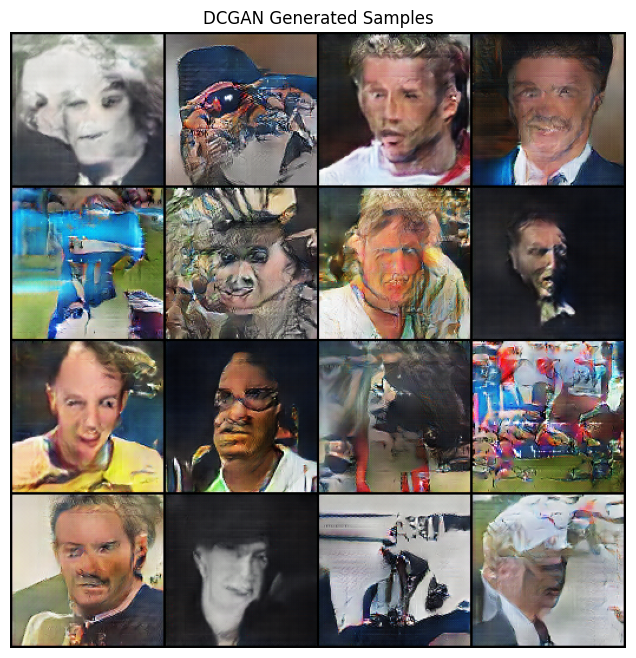

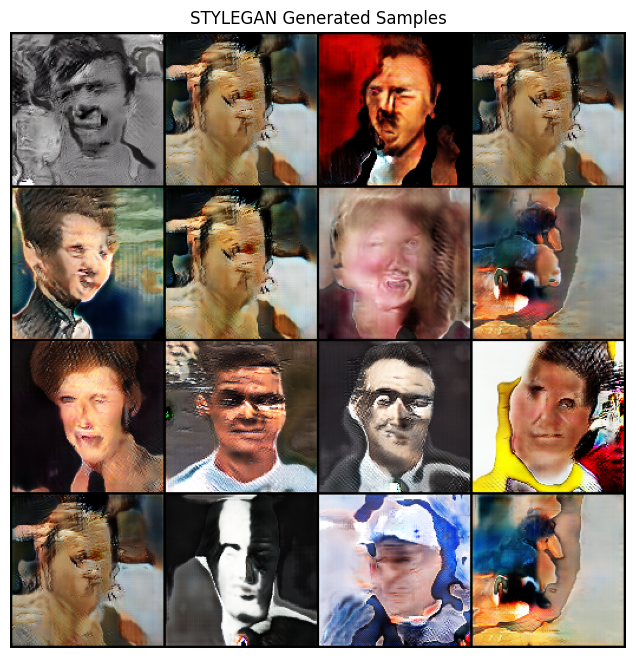

In [ ]:
import torchvision.utils as vutils

def display_generated_images(generator, latent_dim, generator_type='dcgan', n_images=16):
    # Generate latent vectors with appropriate shape
    if generator_type == 'dcgan':
        z = torch.randn(n_images, latent_dim, 1, 1).to(device)
    elif generator_type == 'stylegan':
        z = torch.randn(n_images, latent_dim).to(device)
    else:
        raise ValueError("Unknown generator type.")
    
    generator.eval()
    with torch.no_grad():
        fake_imgs = generator(z).cpu()
    
    # Create a grid of images
    grid = vutils.make_grid(fake_imgs, nrow=4, normalize=True)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"{generator_type.upper()} Generated Samples")
    plt.axis("off")
    plt.show()

# Example usage:
display_generated_images(dcgan_G, latent_dim=100, generator_type='dcgan', n_images=16)
display_generated_images(stylegan_G, latent_dim=512, generator_type='stylegan', n_images=16)